# Web scrapping with EDA

## 1. Installing Required Libraries

In [1]:
import requests
from bs4 import BeautifulSoup
import csv

## 2. Extracting Data from a Website

In [11]:
import csv
import pandas as pd

def save_to_csv(data, filename="quotes.csv"):
    if not data:
        print("No data to save.")
        return

    try:
        with open(filename, "w", newline='', encoding='utf-8') as f:
            writer = csv.DictWriter(f, fieldnames=["Quote", "Author", "Tags"])
            writer.writeheader()
            writer.writerows(data)
        print(f"Saved {len(data)} quotes to {filename}")
    except Exception as e:
        print(f"Failed to save file: {e}")

if __name__ == "__main__":
    scraped_data = scrape_quotes()   # make sure this function returns data
    save_to_csv(scraped_data)

# Load CSV with pandas
file_path = r"quotes.csv"   # if in same folder as notebook
data = pd.read_csv(file_path)
data.head()


Scraping http://quotes.toscrape.com//page/1/
Scraping http://quotes.toscrape.com//page/2/
Scraping http://quotes.toscrape.com//page/3/
Scraping http://quotes.toscrape.com//page/4/
Scraping http://quotes.toscrape.com//page/5/
Scraping http://quotes.toscrape.com//page/6/
Scraping http://quotes.toscrape.com//page/7/
Scraping http://quotes.toscrape.com//page/8/
Scraping http://quotes.toscrape.com//page/9/
Scraping http://quotes.toscrape.com//page/10/
Saved 100 quotes to quotes.csv


,Quote,Author,Tags
0,“The world as we have created it is a process ...,Albert Einstein,"change, deep-thoughts, thinking, world"
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling,"abilities, choices"
2,“There are only two ways to live your life. On...,Albert Einstein,"inspirational, life, live, miracle, miracles"
3,"“The person, be it gentleman or lady, who has ...",Jane Austen,"aliteracy, books, classic, humor"
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe,"be-yourself, inspirational"


## 3. Storing Data into a CSV file

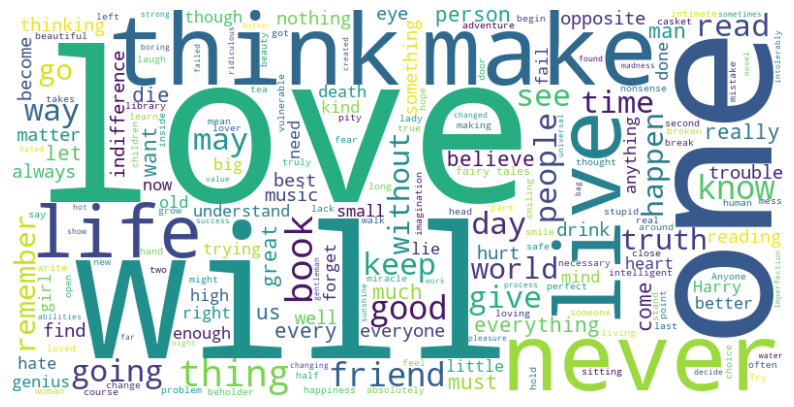

In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_quotes = " ".join(data['Quote'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(all_quotes)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

## 4.2. Top 10 Most Quoted Authors

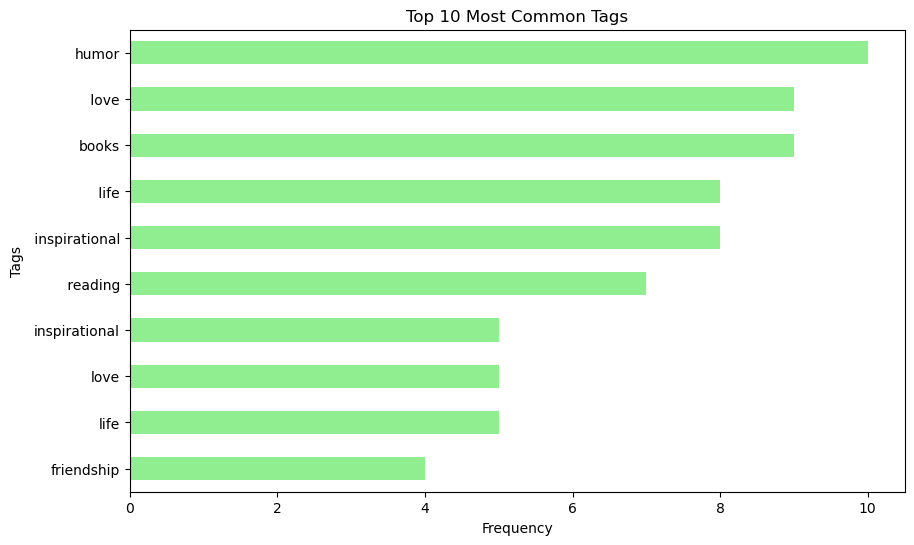

In [14]:
tag_counts = data['Tags'].str.split(',').explode().value_counts()

plt.figure(figsize=(10, 6))
tag_counts.head(10).plot(kind='barh', color='lightgreen')
plt.title("Top 10 Most Common Tags")
plt.xlabel("Frequency")
plt.ylabel("Tags")
plt.gca().invert_yaxis()
plt.show()

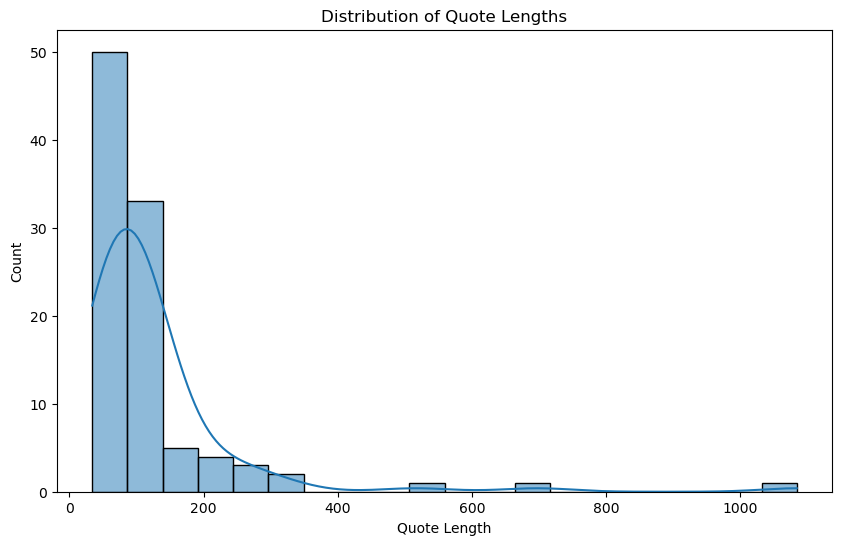

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

data['Quote Length'] = data['Quote'].apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(data['Quote Length'], bins=20, kde=True)
plt.title('Distribution of Quote Lengths')
plt.show()


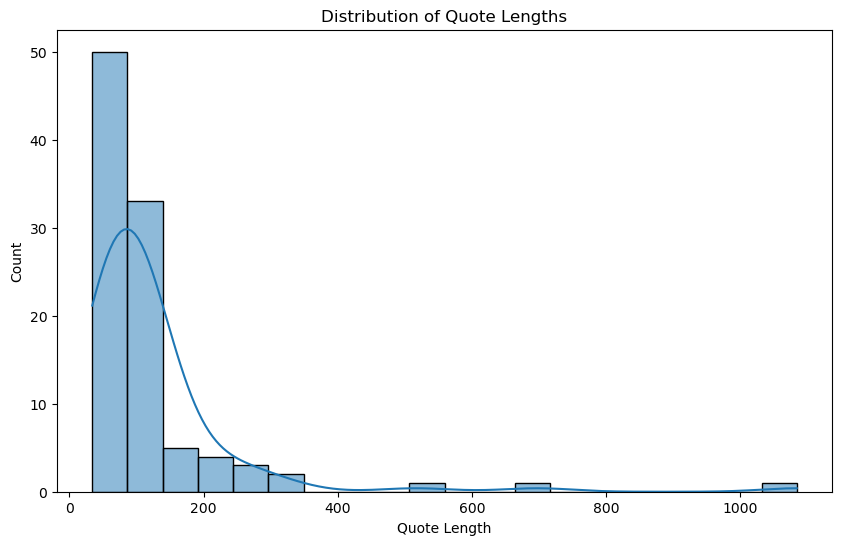

In [16]:
import seaborn as sns

data['Quote Length'] = data['Quote'].apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(data['Quote Length'], bins=20, kde=True)
plt.title('Distribution of Quote Lengths')
plt.show()